In [1]:
import torch

# si ringrazia la gentile partecipazione del server della Prof.ssa Lo Presti per la generazione del dataset (METIS non funziona su Windows)
#dataset = RedditSubGraphDataset(path='Reddit', num_graphs=1000, task_type='a')

dataset = torch.load("reddit_task3_clusters_b.pt", weights_only=False)

In [2]:
#Raccogliamo tutti gli ID unici originali presenti nel dataset
id_originali = set()
for split in ['train', 'val', 'test']:
    for subgraph in dataset[split]:
        id_originali.add(subgraph.y.item())

# Ordiniamo gli ID per avere una mappatura stabile
id_originali = sorted(list(id_originali))
num_classi_reali = len(id_originali)

#Creiamo un dizionario di conversione (es. {160: 0, 185: 1, 190: 2, ...})
mappa_id = {id_vecchio: id_nuovo for id_nuovo, id_vecchio in enumerate(id_originali)}

print(f"Community uniche trovate: {num_classi_reali}")
print(f"Esempio di mappatura: ID originale {id_originali[0]} diventa -> {mappa_id[id_originali[0]]}")

# 3. Applichiamo la rimappatura fisica a tutti i sotto-grafi del dataset
for split in ['train', 'val', 'test']:
    for subgraph in dataset[split]:
        id_vecchio = subgraph.y.item()
        id_nuovo = mappa_id[id_vecchio]
        
        # Sovrascriviamo il target con il nuovo indice compresso (da 0 a 39)
        subgraph.y = torch.tensor(id_nuovo, dtype=torch.long)

print("\n[OK] Rimappatura completata! Ora puoi usare out_channels =", num_classi_reali)

Community uniche trovate: 40
Esempio di mappatura: ID originale 107 diventa -> 0

[OK] Rimappatura completata! Ora puoi usare out_channels = 40


In [3]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(dataset["train"], batch_size=128, shuffle=True)
val_loader = DataLoader(dataset["val"], batch_size=128, shuffle=False)
test_loader = DataLoader(dataset["test"], batch_size=128, shuffle=False)

In [ ]:
import numpy as np
from collections import Counter
from utils_task3_a import train_loop
from utils_task3_b import HierarchicalGCNClassifier,evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr = 2e-4
epochs = 50

# Estraiamo tutte le etichette (già rimappate da 0 a 39) dal train set
train_labels = [subgraph.y.item() for subgraph in dataset['train']]
conteggio_classi = Counter(train_labels)

num_classi = len(set(train_labels))

# Formula del bilanciamento multi-classe: total_samples / (num_classes * class_samples)
totale_campioni = len(train_labels)
pesi_array = np.zeros(num_classi, dtype=np.float32)

for t in range(num_classi):
    if conteggio_classi[t] > 0:
        pesi_array[t] = totale_campioni / (num_classi * conteggio_classi[t])
    else:
        pesi_array[t] = 1.0 # Fallback di sicurezza per classi non presenti nel train

# Convertiamo il vettore dei pesi in tensore e lo mandiamo sulla GPU/CPU
ce_weights = torch.tensor(pesi_array, dtype=torch.float32).to(device)

print(f"Task B - Classi rilevate: {num_classi}")

model = RobustGraphClassifier(
    in_channels=dataset['train'][0].num_features, 
    hidden_channels=256, 
    out_channels=num_classi
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

# Sostituiamo la BCE con la CrossEntropyLoss pesata per il multi-classe
loss_fn = torch.nn.CrossEntropyLoss(weight=ce_weights)

# Cambiamo il nome del file di salvataggio per non sovrascrivere il Task A
best_model_path = "best_model_task3_b_GCN.pth"
scaler = torch.amp.GradScaler()

# Lancio dell'addestramento
history = train_loop(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    loss_fn, 
    device, 
    epochs, 
    best_model_path, 
    scaler,
    patience=15
)

Task B - Classi rilevate: 40


Evaluating...: 100%|██████████| 1/1 [00:00<00:00, 11.17it/s]


Epoch 1/50 - Train Loss: 3.7565 - Val Loss: 3.6781 - Balanced Accuracy: 0.0125 - F1 Score: 0.0007
Nuovo miglior modello salvato con Val Loss: 3.6781
-----------------------------------------------


Evaluating...: 100%|██████████| 1/1 [00:00<00:00, 17.93it/s]


Epoch 2/50 - Train Loss: 3.6641 - Val Loss: 3.6726 - Balanced Accuracy: 0.0381 - F1 Score: 0.0172
Nuovo miglior modello salvato con Val Loss: 3.6726
-----------------------------------------------


...

Epoch 17/50 - Train Loss: 2.7555 - Val Loss: 3.7360 - Balanced Accuracy: 0.0376 - F1 Score: 0.0544
Nessun miglioramento. Contatore di pazienza: 13/15
-----------------------------------------------


Evaluating...: 100%|██████████| 1/1 [00:00<00:00, 20.68it/s]


Epoch 18/50 - Train Loss: 2.6526 - Val Loss: 3.7371 - Balanced Accuracy: 0.0248 - F1 Score: 0.0483
Nessun miglioramento. Contatore di pazienza: 14/15
-----------------------------------------------


Evaluating...: 100%|██████████| 1/1 [00:00<00:00, 18.75it/s]

Epoch 19/50 - Train Loss: 2.5821 - Val Loss: 3.7572 - Balanced Accuracy: 0.0000 - F1 Score: 0.0000
Nessun miglioramento. Contatore di pazienza: 15/15
Early stopping attivato.


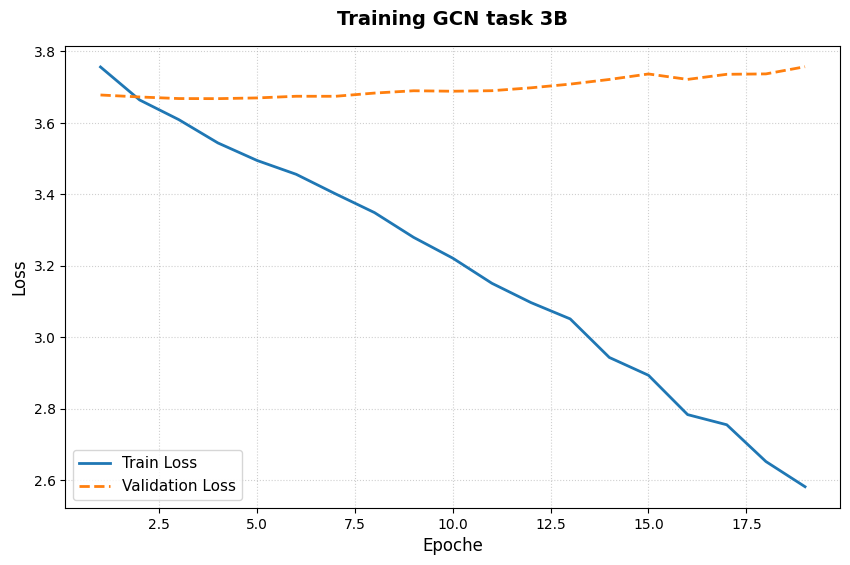

In [7]:
from utils_task3_b import plot_history

plot_history(history,"Training GCN task 3B")

In [8]:
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")


Valutazione sul test set


Evaluating...: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s]

Test Loss: 3.6774 - Balanced Accuracy: 0.0250 - F1 Score: 0.0404
